## Plot Kernel Density Estimate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [2]:
plt.rcParams.update({
     "text.usetex": True,
     "font.family": "serif",
     "font.serif": ["Palatino"],
 })

plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "figure.dpi": 140,
    "axes.linewidth": 1.4,
})

In [3]:
file = "../fake_run/best_fake.dict"  #file recording best performing protomodels from each walk on 15 fake SM databases
fake_bg = np.arange(1,16)

highscoremodel = []  #stores all the best performing protomodels
bestmodel = []      #stores the absolute best performing protomodel (highest K from all walks on a single db)

with open(file,'r') as f:
    models = eval(f.read())
    for fb in fake_bg:
        himodels = [d for d in models if d.get('fake_bg_id') == fb]
        highscoremodel += himodels
        bm = sorted(himodels, key=lambda x: x["K"], reverse=True)[0]
        bestmodel.append(bm)

### Plot KDE (only fake SM)

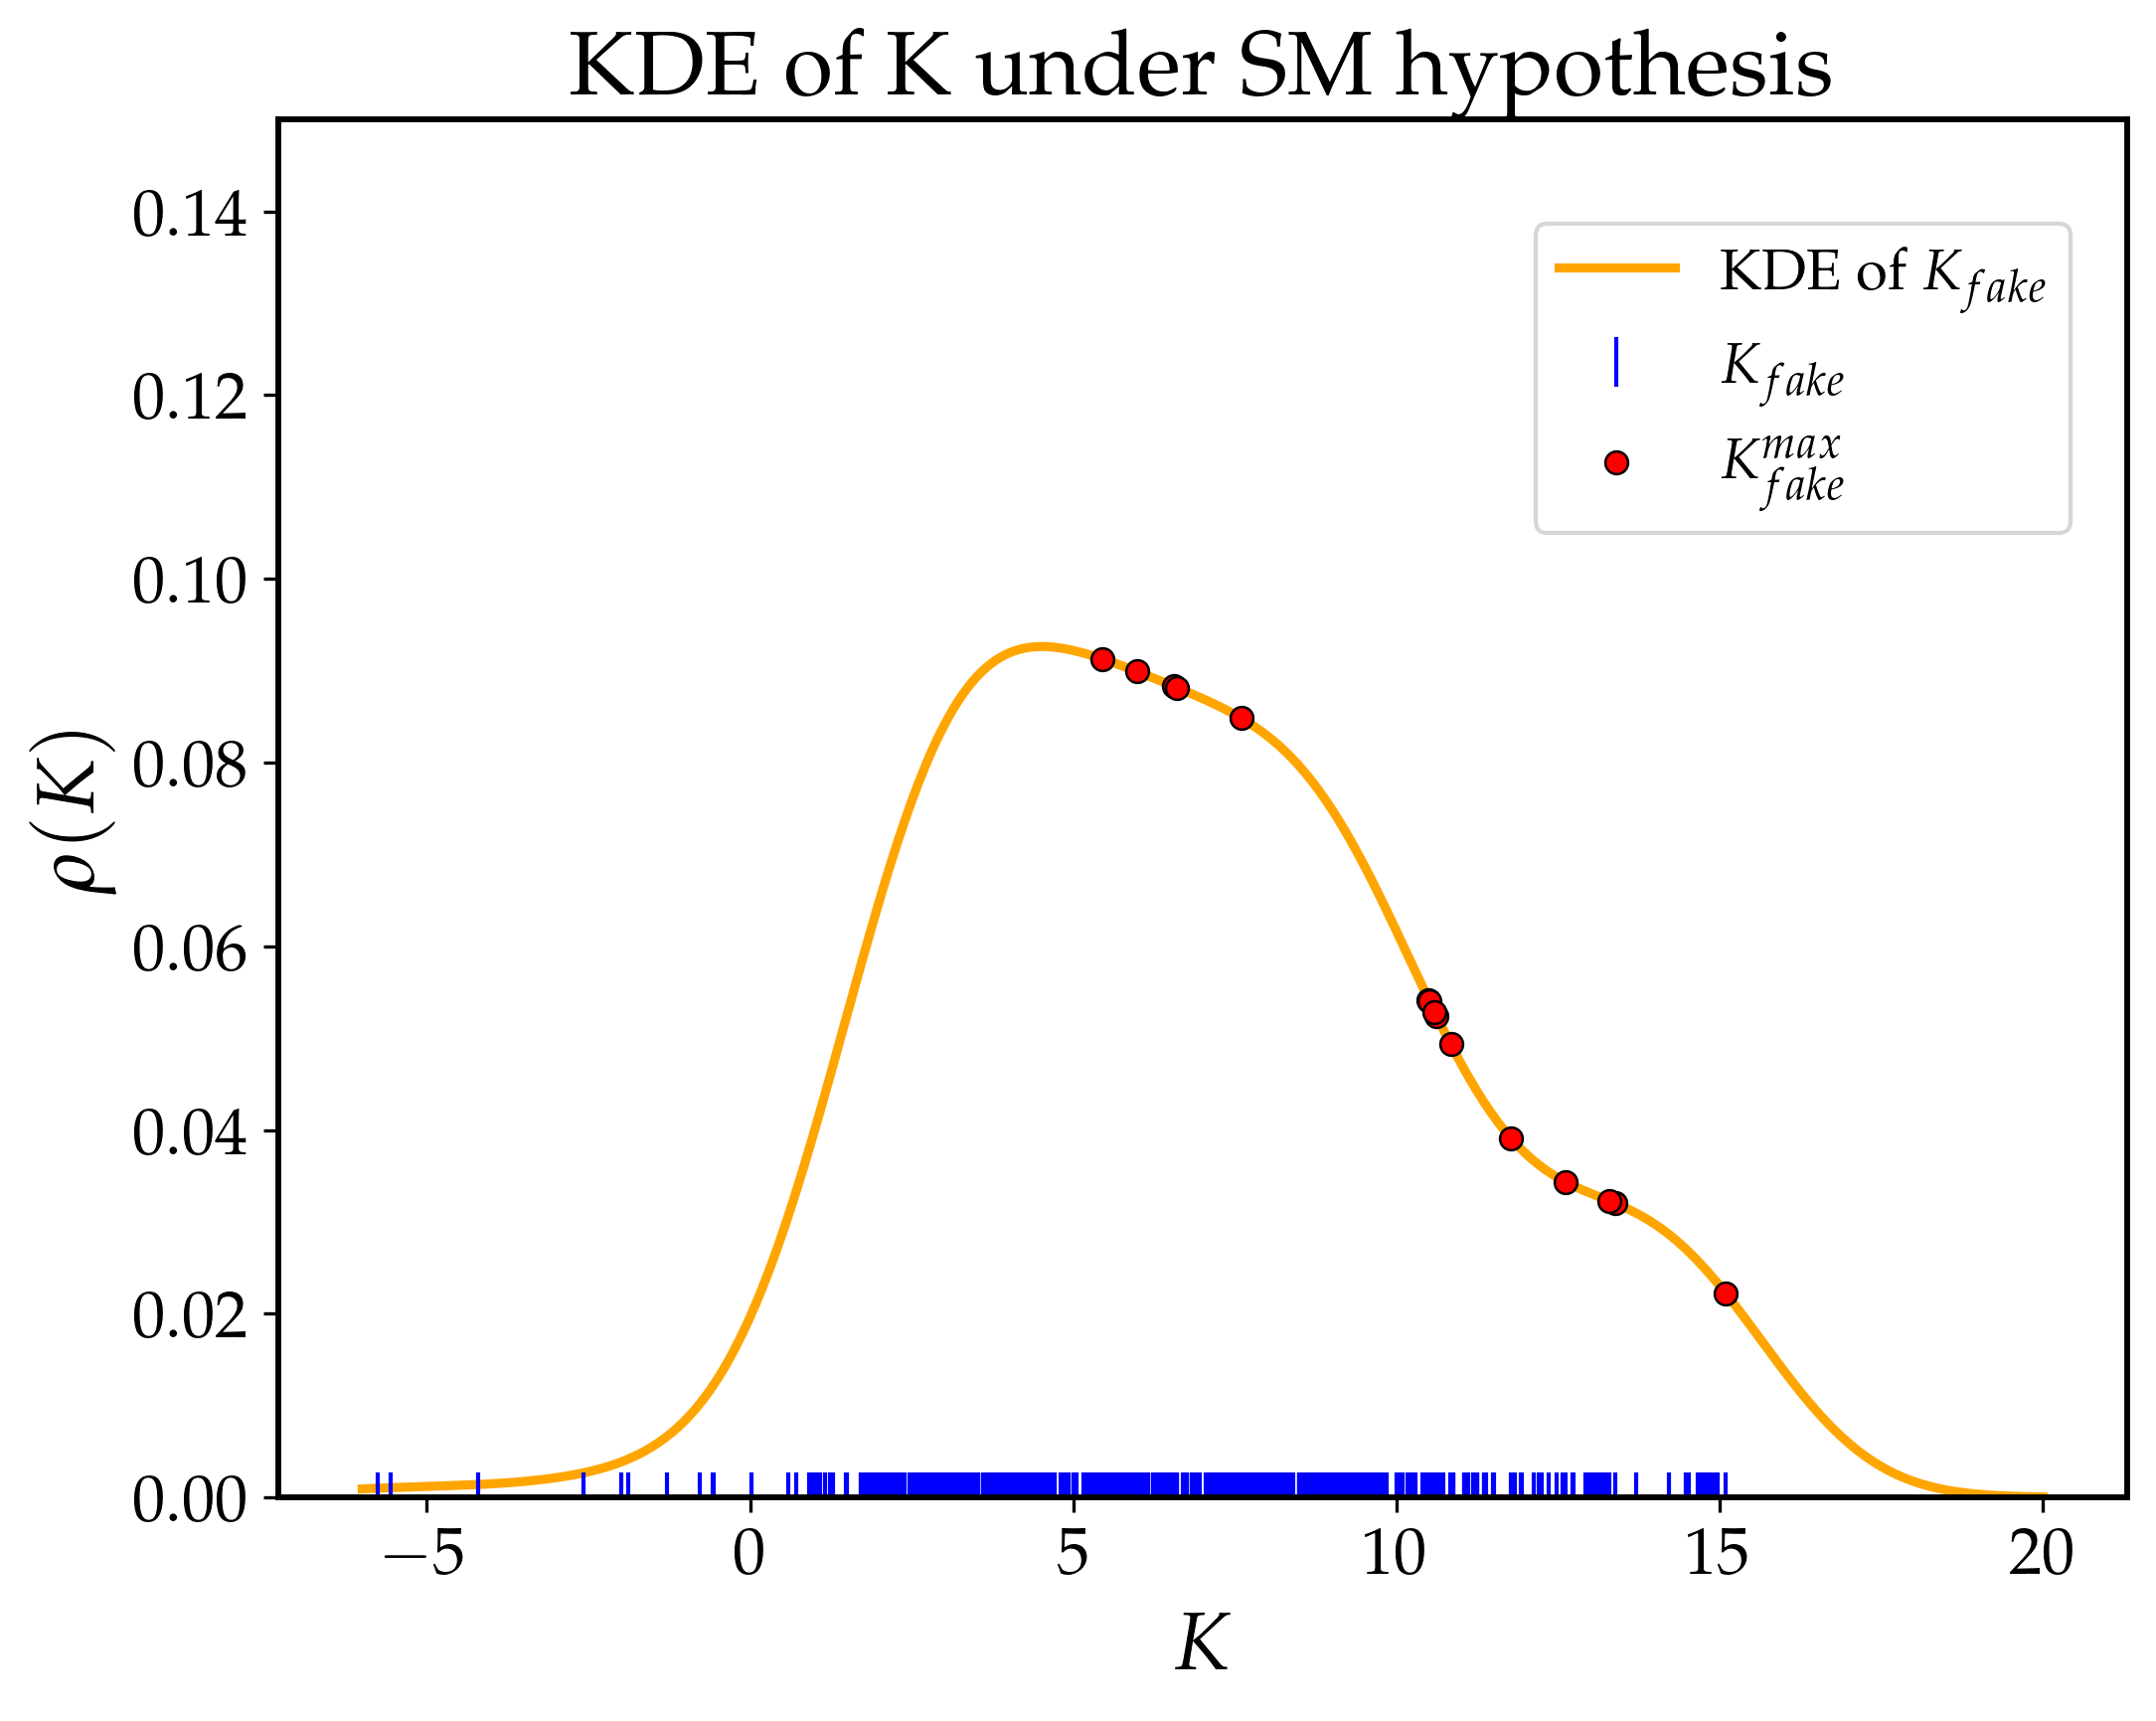

In [6]:
# Create pd dataframe
hidata = pd.DataFrame(highscoremodel)
bestKdata = pd.DataFrame(bestmodel)
K = hidata["K"].values
bestKfake = bestKdata["K"].values


# calculate kde of K
kde = gaussian_kde(K, bw_method="scott")
kde_1p5 = gaussian_kde(K, bw_method=1.5 * kde.factor)  # 1.5x Scott

# x–grid 
x_grid = np.linspace(-6,20,500)

#calculate density on xgrid
y_grid = kde_1p5(x_grid)

# y-values of KDE at each data point
y_points = kde_1p5(bestKfake)


# Plot 
plt.figure(figsize=(8,6), dpi=300)

# KDE curve
plt.plot(x_grid, kde_1p5(x_grid),  linewidth=2.2, color='orange', label=r'KDE of $K_{fake}$')

# Blue marks denoting individual K values 
plt.plot(K, np.zeros(K.shape), 'b|', ms=12, label=r'$K_{fake}$' ) 

#Mark absolute best performing protomodels
plt.scatter(bestKfake, y_points, s=30, edgecolor='black', linewidth=0.6, zorder=3, color='red', label=r'$K_{fake}^{max}$')


plt.xlabel(r"$K$")
plt.ylim(0.0,0.15)
plt.ylabel(r"$\rho(K)$")
plt.title(r"KDE of K under SM hypothesis")
plt.legend(loc=(0.68,0.70))
plt.grid(False)
plt.show()



### Determine global $p$-value

In [7]:
real_file = "../real_run/best_perf_proto.dict"
realhiK = []
with open(real_file, "r") as f:
    dictlist = eval(f.read())
    for d in dictlist:
        realhiK.append(d['K'])

realhiK = sorted(realhiK, reverse=True)
print(realhiK)


[18.29, 16.96, 16.46, 16.42, 16.41, 16.32, 16.31, 16.29, 16.28, 16.27, 16.25, 16.24, 16.24, 16.22, 16.21, 16.2, 16.2, 16.17, 16.16, 16.16, 16.15, 16.14, 16.11, 16.11, 16.1, 16.08, 16.05, 16.02, 16.01, 16.01, 15.99, 15.98, 15.98, 15.98, 15.97, 15.94, 15.92, 15.91, 15.9, 15.83, 15.79, 15.79, 15.73, 15.73, 15.68, 15.67, 15.61, 15.58, 15.47, 15.24]


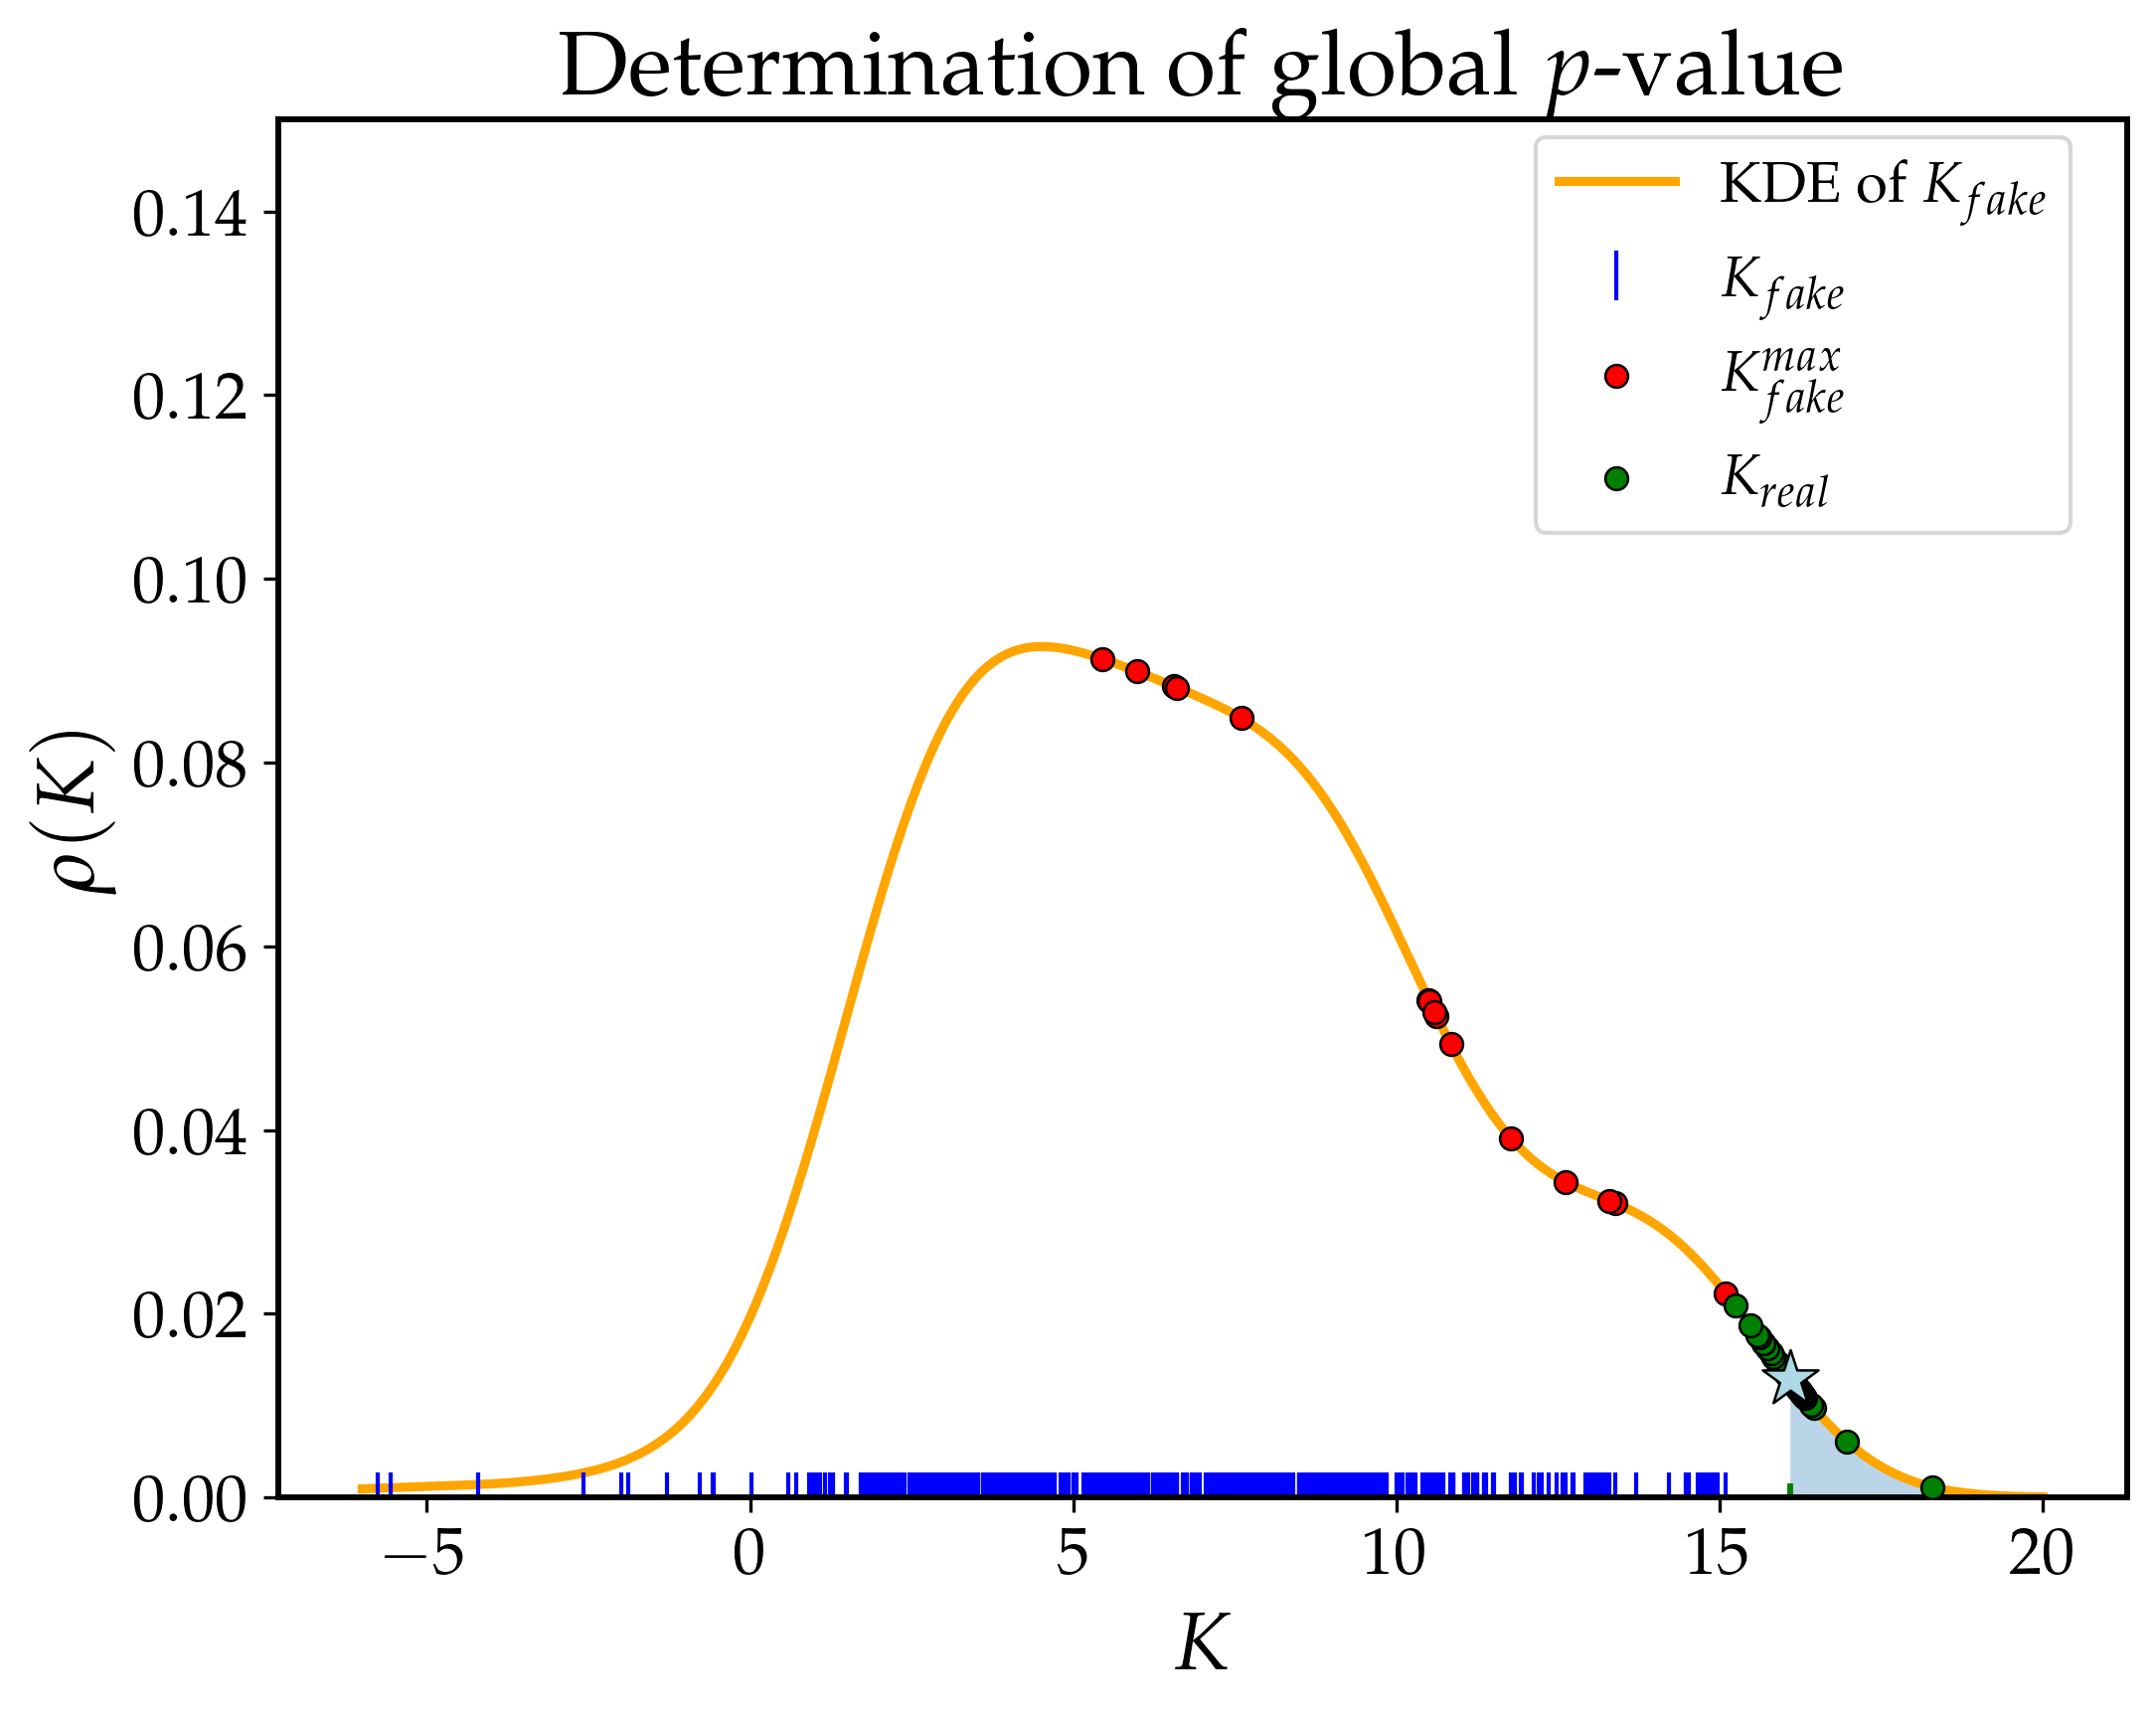

In [8]:
#calcualte density of real K values
real_points = kde_1p5(realhiK)
K_mean = np.mean(realhiK)

#Plot
plt.figure(figsize=(8,6), dpi=300)

# KDE curve
plt.plot(x_grid, kde_1p5(x_grid),  linewidth=2.2, color='orange', label=r'KDE of $K_{fake}$')

# Blue marks denoting individual K values 
plt.plot(K, np.zeros(K.shape), 'b|', ms=12, label=r'$K_{fake}$' ) 

#Mark absolute best performing protomodels
plt.scatter(bestKfake, y_points, s=30, edgecolor='black', linewidth=0.6, zorder=3, color='red', label=r'$K_{fake}^{max}$')

#Mark real K values
plt.scatter(realhiK, real_points, s=30, edgecolor='black', linewidth=0.6, zorder=3, color='green', label=r'$K_{real}$')
plt.scatter([K_mean], kde_1p5(K_mean), s=200, marker='*', edgecolor='black', linewidth=0.6, zorder=3, color='lightblue')

#Vertical line at the mean
plt.axvline(K_mean, ymin=0.0, ymax=kde(K_mean)[0], color="green", linestyle="--", linewidth=1.4)

# Shade the region right of the mean
plt.fill_between(x_grid, y_grid, where=(x_grid >= K_mean), alpha=0.3)

plt.xlabel(r"$K$")
plt.ylim(0.0,0.15)
plt.ylabel(r"$\rho(K)$")
plt.title(r"Determination of global $p$-value")
plt.legend(loc=(0.68,0.70))
plt.grid(False)

plt.show()



In [9]:
#Calculate p-value
from scipy.integrate import quad
def kde_pvalue_right_tail(kde, T):
    val,_ = quad(kde_1p5, T, np.inf)
    return val


p = kde_pvalue_right_tail(kde_1p5, K_mean)
print("Global p-value: ", round(p,3))

Global p-value:  0.013
